In [6]:
!pip install -U tabpfn

In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from tabpfn import TabPFNClassifier

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    classification_report,
    confusion_matrix,
    roc_curve,
    auc
)

import joblib

In [8]:
from google.colab import files

uploaded = files.upload()

Saving final_test_processed.csv to final_test_processed (1).csv
Saving final_train_processed.csv to final_train_processed (1).csv


In [9]:
import pandas as pd

df = pd.read_csv("final_train_processed.csv")
df = pd.read_csv("final_test_processed.csv")

print(df.shape)
df.head()

(1914, 18)


,CreditScore,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Geography_Germany,Geography_Spain,BalanceSalaryRatio,TenureByAge,BalancePerProduct,ProductsPerTenure,ActiveWithCard,IsZeroBalance,Exited
0,0.196483,0,0.193211,1.394672,-1.341260,0.878882,0,0,0.615301,0,0,-0.034391,0.961455,-1.195658,-0.458065,0,1,0
1,1.130834,1,-1.182269,0.011320,0.353342,0.878882,0,1,-0.244237,1,0,-0.028813,0.474536,-0.288717,-0.063557,0,0,0
2,0.637989,0,-1.182269,0.702996,1.066331,-0.772148,1,1,-0.268687,1,0,-0.026335,1.276520,1.381400,-0.679976,1,0,0
3,0.196483,1,-1.605493,-1.372033,1.240514,-0.772148,0,0,-1.094971,0,0,-0.014848,-1.065275,1.567844,0.429578,0,0,1
4,-0.265559,0,-0.441626,-1.717871,-1.341260,0.878882,1,0,0.196402,0,1,-0.034391,-1.530426,-1.195658,4.867794,0,1,0


In [10]:
X = df.drop("Exited", axis=1)
y = df["Exited"]

print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (1914, 17)
y shape: (1914,)


In [11]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training set:", X_train.shape)
print("Testing set:", X_test.shape)

Training set: (1531, 17)
Testing set: (383, 17)


In [16]:
import os

os.environ["TABPFN_TOKEN"] = "tabpfn_sk_SFdEkBPD9MTHBWtEOFyGSE5nvtnkbfJLD_cIvdUrJtg"

In [17]:
token = os.environ.get("TABPFN_TOKEN", "")

print("Token exists:", bool(token))
print("Token length:", len(token))
print("Contains non-ASCII:", any(ord(c) > 127 for c in token))
print("Contains ellipsis:", "…" in token)

Token exists: True
Token length: 53
Contains non-ASCII: False
Contains ellipsis: False


In [28]:
from tabpfn import TabPFNClassifier

tabpfn_clf = TabPFNClassifier(
    device="cpu",
    random_state=42,
    ignore_pretraining_limits=True
)

tabpfn_clf.fit(
    X_train,
    y_train
)

print("TabPFN training completed!")

TabPFN training completed!


In [31]:
y_pred = tabpfn_clf.predict(X_test)

y_pred_proba = tabpfn_clf.predict_proba(X_test)[:, 1]

print("Prediction completed!")

Prediction completed!


In [32]:
accuracy = accuracy_score(y_test, y_pred)

precision = precision_score(
    y_test,
    y_pred
)

recall = recall_score(
    y_test,
    y_pred
)

f1 = f1_score(
    y_test,
    y_pred
)

roc_auc = roc_auc_score(
    y_test,
    y_pred_proba
)

print("TabPFN Results")
print("-------------------------")
print(f"Accuracy : {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall   : {recall:.4f}")
print(f"F1 Score : {f1:.4f}")
print(f"ROC-AUC  : {roc_auc:.4f}")

TabPFN Results
-------------------------
Accuracy : 0.8799
Precision: 0.7419
Recall   : 0.6053
F1 Score : 0.6667
ROC-AUC  : 0.9065


In [33]:
print("\nClassification Report:")

print(
    classification_report(
        y_test,
        y_pred
    )
)


Classification Report:
              precision    recall  f1-score   support

           0       0.91      0.95      0.93       307
           1       0.74      0.61      0.67        76

    accuracy                           0.88       383
   macro avg       0.82      0.78      0.80       383
weighted avg       0.87      0.88      0.88       383



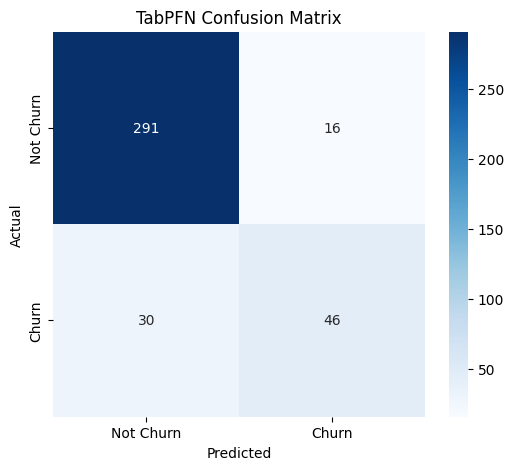

In [34]:
cm = confusion_matrix(
    y_test,
    y_pred
)

plt.figure(figsize=(6, 5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Not Churn", "Churn"],
    yticklabels=["Not Churn", "Churn"]
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("TabPFN Confusion Matrix")

plt.show()

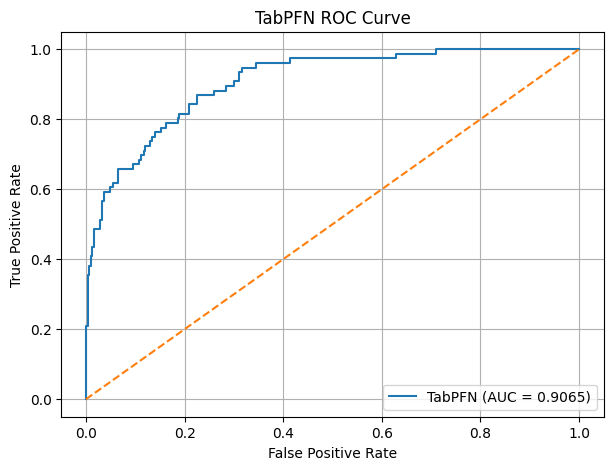

In [35]:
fpr, tpr, thresholds = roc_curve(
    y_test,
    y_pred_proba
)

roc_auc = auc(
    fpr,
    tpr
)

plt.figure(figsize=(7, 5))

plt.plot(
    fpr,
    tpr,
    label=f"TabPFN (AUC = {roc_auc:.4f})"
)

plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--"
)

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("TabPFN ROC Curve")

plt.legend()
plt.grid()

plt.show()

In [36]:
joblib.dump(
    tabpfn_model,
    "tabpfn_model.pkl"
)

print("TabPFN model saved successfully!")

TabPFN model saved successfully!


In [37]:
tabpfn_results = pd.DataFrame({
    "Model": ["TabPFN"],
    "Accuracy": [accuracy],
    "Precision": [precision],
    "Recall": [recall],
    "F1_Score": [f1],
    "ROC_AUC": [roc_auc]
})

tabpfn_results.to_csv(
    "tabpfn_results.csv",
    index=False
)

print(tabpfn_results)

    Model  Accuracy  Precision    Recall  F1_Score  ROC_AUC
0  TabPFN  0.879896   0.741935  0.605263  0.666667  0.90648


In [38]:
tabpfn_predictions = pd.DataFrame({
    "Actual": y_test.values,
    "Predicted": y_pred,
    "Probability": y_pred_proba
})

tabpfn_predictions.to_csv(
    "tabpfn_predictions.csv",
    index=False
)

print("TabPFN predictions saved successfully!")

TabPFN predictions saved successfully!
